## Tâches dans ce notebook:
  - Sélectionner trois couleurs distinctes.
  - Attribuer une couleur à chaque province de Madagascar, en veillant à utiliser uniquement les trois couleurs choisies.
  - S'assurer qu'aucune province voisine ne partage la même couleur.

## Provinces de Madagascar non colorées

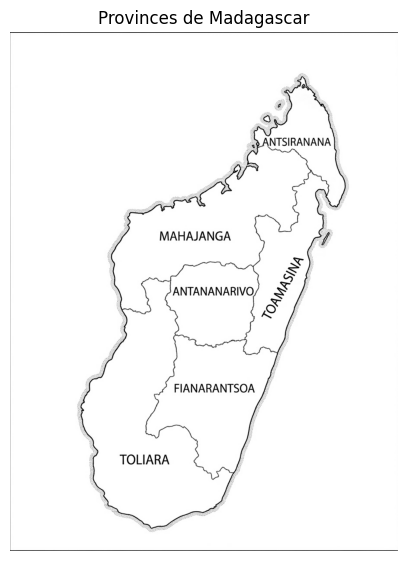

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

img_pil = Image.open('provinces.png').convert('L')
plt.imshow(img_pil, cmap='gray')
plt.axis('off')
plt.title("Provinces de Madagascar")
plt.gcf().set_size_inches(5, 7)
plt.show()

## Liens entre provinces

In [2]:
# Madagascar's provinces and their neighboring links
MDG_PROVINCES = {
    "Antsiranana": ["Mahajanga", "Toamasina"],
    "Mahajanga": ["Antsiranana", "Toamasina", "Antananarivo", "Toliara"],
    "Toamasina": ["Antsiranana", "Mahajanga", "Antananarivo", "Fianarantsoa"],
    "Antananarivo": ["Mahajanga", "Toamasina", "Fianarantsoa", "Toliara"],
    "Fianarantsoa": ["Toamasina", "Antananarivo", "Toliara"],
    "Toliara": ["Mahajanga", "Antananarivo", "Fianarantsoa"]
}

COLORS = {
    "orange": (255, 179, 102),  # orange
    "bleue": (144, 202, 249),  # bleue
    "light green": (165, 214, 167),  # light green
}

## Recherche des bonnes couleurs pour la coloration

In [3]:
from itertools import product 

def valid_colors(colors, nbs):
    for pv, pc in colors.items():
        if any(colors[nb]==pc for nb in nbs[pv]):
            return False
    return True

def find_colors(base_colors, nbs):
    for perm in product(base_colors.keys(),repeat=6):
        colors = {prv: cl for prv,cl in zip(nbs.keys(), perm)}
        if valid_colors(colors, nbs):
            return colors
        
    return None

In [4]:
SOLUTION = find_colors(COLORS, MDG_PROVINCES)
assert SOLUTION is not None, "Did not find any solution"

print("Solution found:")
print(*SOLUTION.items(), sep="\n")

Solution found:
('Antsiranana', 'orange')
('Mahajanga', 'bleue')
('Toamasina', 'light green')
('Antananarivo', 'orange')
('Fianarantsoa', 'bleue')
('Toliara', 'light green')


## Affichage de solutions

In [5]:
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt

In [6]:
def plot_solution(img_pil, colors, plot_title):
    # 1. Load img gray
    gray = np.array(img_pil)

    # 2. Binarize edges and interior
    borders = (gray > 150).astype(np.uint8) * 255

    # 3. Label closed regions
    labeled = measure.label(borders, connectivity=1)
    regions = measure.regionprops(labeled)

    # 4. Filtrer small regions (noises)
    MIN_AREA = 3000
    # Filter huge region (Out of the Madagascar's area)
    MAX_AREA = 100000
    provinces = [r for r in regions if MIN_AREA < r.area < MAX_AREA]

    # 5. Construct color map
    output = np.ones((*gray.shape, 3), dtype=np.uint8) * 255 
    for i, region in enumerate(provinces):
        output[labeled == region.label] = colors[i % len(colors)]

    # 6. Show colored map
    _fig, ax = plt.subplots(figsize=(5, 7))
    ax.imshow(output)

    ax.axis('off')
    ax.set_title(plot_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Provinces de Madagascar colorée

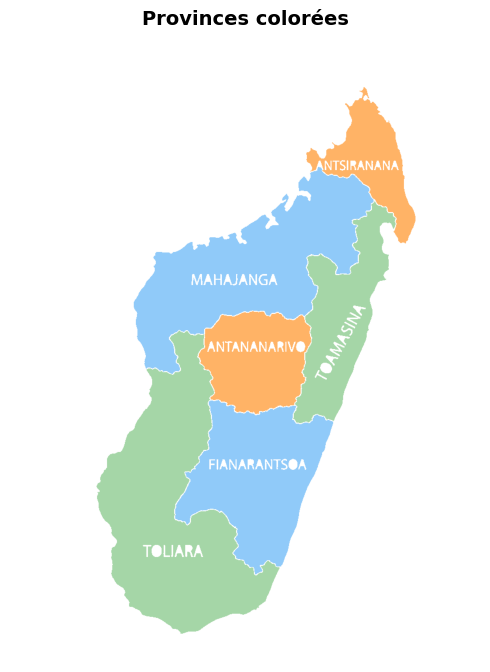

In [7]:
show_order = ["Antsiranana", "Mahajanga", "Toamasina", "Antananarivo", "Toliara", "Fianarantsoa"]
sol_colors = [COLORS[SOLUTION[prv]] for prv in show_order]
plot_solution(img_pil, sol_colors, "Provinces colorées")